/var/folders/qb/cnb_ccp14psg2v1y1f5w5r1h0000gn/T/ipykernel_3182/3176304563.py:15: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method='linear')
/opt/miniconda3/envs/env_d2l/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/env_d2l/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/env_d2l/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/env_d2l/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/env_d2l/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeW

训练集维度: (20948, 252)
测试集维度: (5228, 252)
开始训练模型...


/opt/miniconda3/envs/env_d2l/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/env_d2l/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/env_d2l/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/env_d2l/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/env_d2l/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/env_d2l/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/env_d2l/lib/python3.10/site-packages/sklearn/utils/extmath.py:2

训练完成！

模型评估结果:
RMSE (均方根误差): 4.3092
MAE (平均绝对误差): 2.9174
R2 Score (拟合优度): 0.9637


/opt/miniconda3/envs/env_d2l/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/env_d2l/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/env_d2l/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


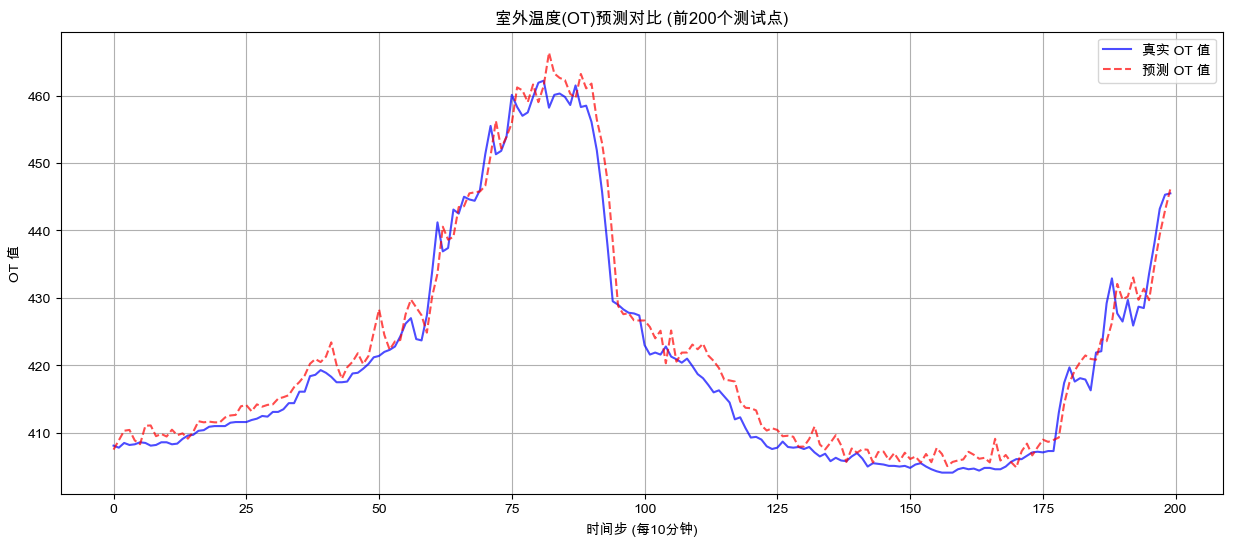

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
# 1. 加载数据与清洗
df = pd.read_csv('weather.csv',encoding='gbk')

# [关键步骤] 处理异常值：将 -9999 视为缺失值并插值填补
# 统计学直觉：气温不会突变为-9999，这属于测量误差
df = df.replace(-9999, np.nan)
df = df.interpolate(method='linear')

# 去除非数值的日期列，仅保留气象指标
data_numeric = df.drop(columns=['date'])
target_col_idx = list(data_numeric.columns).index('OT') # 找到OT列的索引

# 2. 划分训练集与测试集 (时间序列必须按顺序切分)
train_size = int(len(data_numeric) * 0.8)
train_df = data_numeric.iloc[:train_size]
test_df = data_numeric.iloc[train_size:]

# 3. 特征标准化 (Standardization)
scaler = StandardScaler()
scaler.fit(train_df) # 仅在训练集上计算均值和方差

train_scaled = scaler.transform(train_df)
test_scaled = scaler.transform(test_df)

# 4. 构建滑动窗口数据集
def create_dataset(dataset, look_back=12, target_idx=-1):
    """
    根据过去 look_back 个时间点预测下一个时间点的 target_idx 列
    """
    X, y = [], []
    for i in range(len(dataset) - look_back):
        # 取过去 look_back 行的所有特征作为输入
        X.append(dataset[i:(i + look_back), :])
        # 取下一个时间点的 OT 值作为输出
        y.append(dataset[i + look_back, target_idx])
    return np.array(X), np.array(y)

LOOK_BACK = 12 # 过去2小时 (12 * 10min)

X_train_window, y_train = create_dataset(train_scaled, LOOK_BACK, target_col_idx)
X_test_window, y_test = create_dataset(test_scaled, LOOK_BACK, target_col_idx)

# MLP需要将 (样本数, 时间步, 特征数) 展平为 (样本数, 时间步*特征数)
n_train, steps, n_features = X_train_window.shape
X_train_flat = X_train_window.reshape(n_train, steps * n_features)
X_test_flat = X_test_window.reshape(len(X_test_window), steps * n_features)

print(f"训练集维度: {X_train_flat.shape}")
print(f"测试集维度: {X_test_flat.shape}")

# 5. 建立并训练 MLP 模型
# 两个隐藏层 (64, 32)，ReLU激活函数
model = MLPRegressor(hidden_layer_sizes=(64, 32), 
                     activation='relu', 
                     solver='adam', 
                     max_iter=100, 
                     random_state=42,
                     early_stopping=True) # 防止过拟合

print("开始训练模型...")
model.fit(X_train_flat, y_train)
print("训练完成！")

# 6. 预测与反归一化
y_pred_scaled = model.predict(X_test_flat)

# 反归一化：我们需要还原OT的真实数值单位
# 技巧：由于Scaler是针对21列的，我们需要构造一个形状匹配的矩阵来逆变换
def inverse_transform_target(y_scaled, scaler, target_idx, n_features):
    dummy = np.zeros((len(y_scaled), n_features))
    dummy[:, target_idx] = y_scaled
    return scaler.inverse_transform(dummy)[:, target_idx]

y_test_true = inverse_transform_target(y_test, scaler, target_col_idx, n_features)
y_test_pred = inverse_transform_target(y_pred_scaled, scaler, target_col_idx, n_features)

# 7. 模型评估
rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
mae = mean_absolute_error(y_test_true, y_test_pred)
r2 = r2_score(y_test_true, y_test_pred)

print(f"\n模型评估结果:")
print(f"RMSE (均方根误差): {rmse:.4f}")
print(f"MAE (平均绝对误差): {mae:.4f}")
print(f"R2 Score (拟合优度): {r2:.4f}")

# 8. 可视化 (取前200个点展示细节)
plt.figure(figsize=(15, 6))
plt.plot(y_test_true[:200], label='真实 OT 值', color='blue', alpha=0.7)
plt.plot(y_test_pred[:200], label='预测 OT 值', color='red', linestyle='--', alpha=0.7)
plt.title('室外温度(OT)预测对比 (前200个测试点)')
plt.xlabel('时间步 (每10分钟)')
plt.ylabel('OT 值')
plt.legend()
plt.grid(True)
plt.savefig('weather.png')
plt.show()